# Paddy Yield Prediction Using Random Forest

This notebook builds a supervised machine learning regression model to predict paddy yield using agricultural, soil, fertilizer, weather, and humidity-related features.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [2]:
file_path = '../data/paddydataset.csv'
df = pd.read_csv(file_path)

# Clean up column names so they are easier to work with.
df.columns = df.columns.str.strip()
df.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,Pest_60Day(in ml),30DRain( in mm),30DAI(in mm),30_50DRain( in mm),30_50DAI(in mm),51_70DRain(in mm),51_70AI(in mm),71_105DRain(in mm),71_105DAI(in mm),Min temp_D1_D30,Max temp_D1_D30,Min temp_D31_D60,Max temp_D31_D60,Min temp_D61_D90,Max temp_D61_D90,Min temp_D91_D120,Max temp_D91_D120,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,12,162.78,62.28,90,3600,19.6,20.4,187.2,270.8,167.0,250.0,61.0,64.0,18.5,34,16.0,30,15.5,31.0,16.0,33.0,4,10,8,10,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,12,162.78,62.28,90,3600,19.6,20.4,187.2,270.8,167.0,250.0,61.0,64.0,19.5,34,18.5,35,17.0,32.5,16.0,30.5,10,4,10,6,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,12,162.78,62.28,90,3600,18.5,21.5,185.2,272.8,165.3,251.7,60.0,65.0,20.0,35,18.0,30,17.5,33.5,18.0,33.0,4,12,4,12,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,12,162.78,62.28,90,3600,18.5,21.5,185.2,272.8,165.3,251.7,60.0,65.0,19.0,33,17.0,32,16.5,31.5,15.5,32.5,8,6,8,6,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,12,162.78,62.28,90,3600,18.1,21.9,185.6,272.4,166.1,250.9,60.2,64.8,20.5,32,17.5,28,18.0,34.0,16.5,35.0,10,12,10,12,SSE,W,SW,NW,72.7,91,83,81,600,34044


## 3. Explore The Dataset

In [3]:
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Shape: (2789, 45)

Data types:
Hectares                                int64
Agriblock                                 str
Variety                                   str
Soil Types                                str
Seedrate(in Kg)                         int64
LP_Mainfield(in Tonnes)               float64
Nursery                                   str
Nursery area (Cents)                    int64
LP_nurseryarea(in Tonnes)               int64
DAP_20days                              int64
Weed28D_thiobencarb                     int64
Urea_40Days                           float64
Potassh_50Days                        float64
Micronutrients_70Days                   int64
Pest_60Day(in ml)                       int64
30DRain( in mm)                       float64
30DAI(in mm)                          float64
30_50DRain( in mm)                    float64
30_50DAI(in mm)                       float64
51_70DRain(in mm)                     float64
51_70AI(in mm)                        float64
71_

In [4]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hectares,2789.0,NaN,NaN,NaN,3.717461,1.437777,1.0,3.0,4.0,5.0,6.0
Agriblock,2789,6,Sankarapuram,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variety,2789,3,ponmani,1061,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soil Types,2789,2,clay,1521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seedrate(in Kg),2789.0,NaN,NaN,NaN,92.936536,35.94442,25.0,75.0,100.0,125.0,150.0
LP_Mainfield(in Tonnes),2789.0,NaN,NaN,NaN,46.468268,17.97221,12.5,37.5,50.0,62.5,75.0
Nursery,2789,2,dry,1540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nursery area (Cents),2789.0,NaN,NaN,NaN,74.349229,28.755536,20.0,60.0,80.0,100.0,120.0
LP_nurseryarea(in Tonnes),2789.0,NaN,NaN,NaN,3.717461,1.437777,1.0,3.0,4.0,5.0,6.0
DAP_20days,2789.0,NaN,NaN,NaN,148.698458,57.511072,40.0,120.0,160.0,200.0,240.0


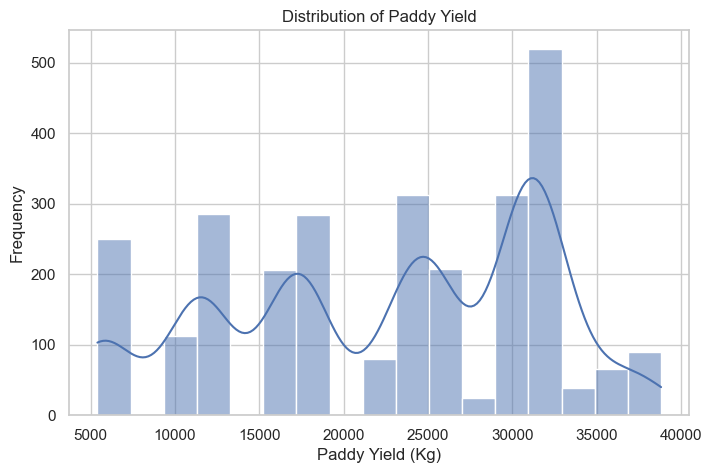

In [5]:
target_column = 'Paddy yield(in Kg)'

plt.figure(figsize=(8, 5))
sns.histplot(df[target_column], kde=True)
plt.title('Distribution of Paddy Yield')
plt.xlabel('Paddy Yield (Kg)')
plt.ylabel('Frequency')
plt.show()

## 4. Prepare Features And Target

In [6]:
X = df.drop(columns=[target_column])
y = df[target_column]

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical features:', categorical_features)
print('\nNumber of numerical features:', len(numerical_features))

Categorical features: ['Agriblock', 'Variety', 'Soil Types', 'Nursery', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind Direction_D61_D90', 'Wind Direction_D91_D120']

Number of numerical features: 36


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (2231, 44)
Testing set shape: (558, 44)


## 5. Build Preprocessing And Baseline Random Forest Model

In [8]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [9]:
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

## 6. Evaluate Baseline Model

In [10]:
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_mse = mean_squared_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_predictions)

baseline_results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Baseline Random Forest': [baseline_mae, baseline_mse, baseline_rmse, baseline_r2]
})

baseline_results

,Metric,Baseline Random Forest
0,MAE,632.614469
1,MSE,786852.240129
2,RMSE,887.046921
3,R2,0.990299


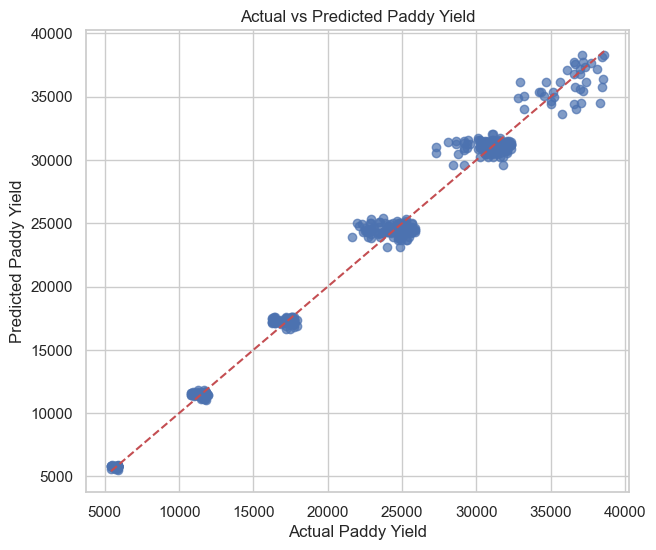

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, baseline_predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Paddy Yield')
plt.ylabel('Predicted Paddy Yield')
plt.title('Actual vs Predicted Paddy Yield')
plt.show()

## 7. Hyperparameter Tuning

In [12]:
param_distributions = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=baseline_model,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
best_predictions = best_model.predict(X_test)

print('Best parameters:')
print(random_search.best_params_)

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}


## 8. Evaluate Tuned Model

In [13]:
tuned_mae = mean_absolute_error(y_test, best_predictions)
tuned_mse = mean_squared_error(y_test, best_predictions)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, best_predictions)

comparison_results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Baseline Random Forest': [baseline_mae, baseline_mse, baseline_rmse, baseline_r2],
    'Tuned Random Forest': [tuned_mae, tuned_mse, tuned_rmse, tuned_r2]
})

comparison_results

,Metric,Baseline Random Forest,Tuned Random Forest
0,MAE,632.614469,608.871898
1,MSE,786852.240129,731524.841462
2,RMSE,887.046921,855.292255
3,R2,0.990299,0.990981


## 9. Feature Importance

In [14]:
encoded_feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_importances = best_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': encoded_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(15)

,Feature,Importance
2,num__LP_Mainfield(in Tonnes),0.112667
10,num__Pest_60Day(in ml),0.098700
1,num__Seedrate(in Kg),0.097123
0,num__Hectares,0.094957
5,num__DAP_20days,0.086654
4,num__LP_nurseryarea(in Tonnes),0.081983
9,num__Micronutrients_70Days,0.079184
3,num__Nursery area (Cents),0.074964
7,num__Urea_40Days,0.073523
35,num__Trash(in bundles),0.068900


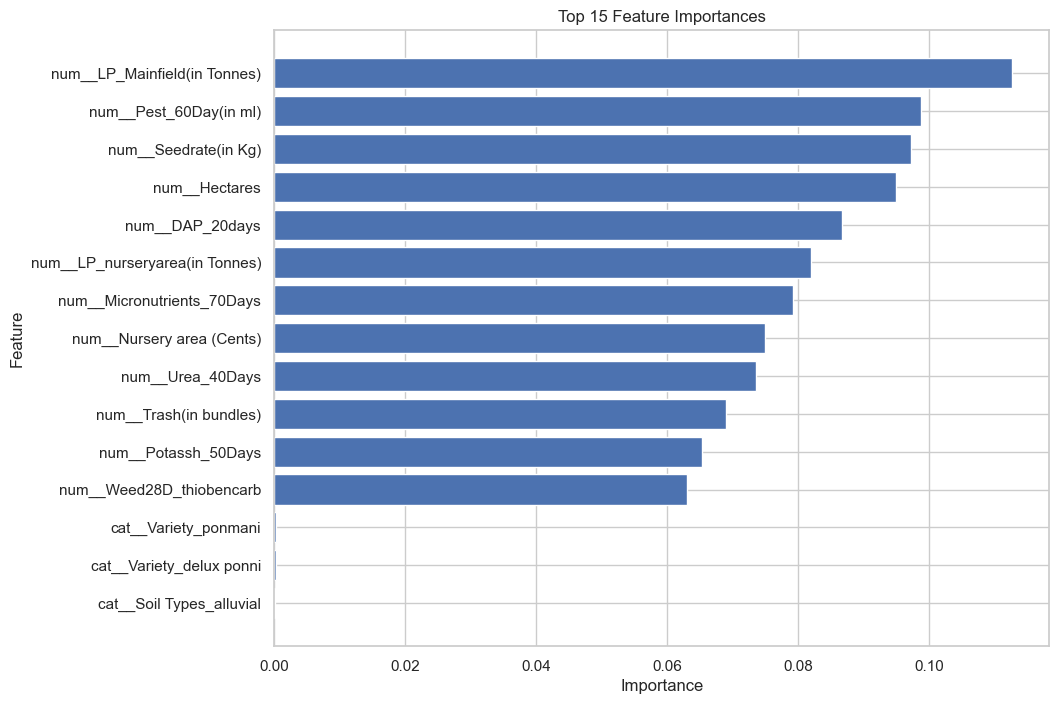

In [15]:
top_features = importance_df.head(15).sort_values(by='Importance')

plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 10. Final Notes For Report

- Mention that this is a regression problem.
- Explain why Random Forest is suitable for mixed agricultural and environmental features.
- Compare your final metrics with the other three group algorithms.
- Discuss limitations such as dataset size, feature quality, or missing real-world factors.